图片中所有非白色部分的灰度值之和小于某个阈值之后就应用亮度遮罩算法。这个阈值由本工具进行计算。
- 暂时只支持单张典型图片输入

In [1]:
import cv2
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))

from utils import ImageIO,  ImageOps

In [4]:
def measure_darkness(img: np.ndarray, white_thr: int = 240) -> float:
    """返回非白色像素的占比 （用于确定 adaptive_darken 的触发阈值）"""
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img
    mask = gray < white_thr
    lines_martix = gray[mask]
    darkness = np.average(lines_martix)
    return float(np.sum(mask)) / (gray.shape[0] * gray.shape[1]), darkness  # 归一化到[0, 255]范围内

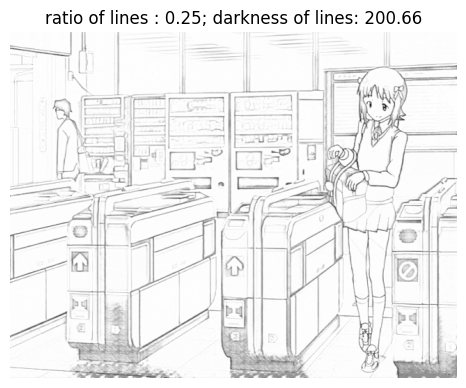

In [5]:
img_np = ImageIO.read_gray("test2.png")
ImageIO.show_images([img_np], titles=[f"ratio of lines : {measure_darkness(img_np)[0]:.2f}; darkness of lines: {measure_darkness(img_np)[1]:.2f}"])